In [154]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import scipy as sp 
import scipy.stats as sps
import astropy
from astropy.io import fits
plt.style.use('dark_background')
pd.options.display.float_format = '{:.4f}'.format

# Assignment 2

## Exercise 1: Initial Setup and computing the cluster centre and radii

## 1.a.

(to delete later for conservative space in notebook)

(a) First, load in the stars data as shown in Assignment 1. Then load the list of clusters in assignment2_clusters.dat
into a pandas Series object. To assign a cluster, write down the last four digits of your StudentID 𝑘, and compute
your unique cluster ID using those numbers and the length of the list you loaded from
assignment2_clusters.dat :

cluster_index = k % len(assigment2_clusters)

cluster_name = assigment2_clusters.iloc[cluster_index]

Here, the % symbol computes the modulo (remainder after dividing k by the length of the cluster dataframe). In your
notebook, be sure you note down k, the cluster index and the name of the cluster you will be working with.

In [155]:
gaia_file = '/Users/leayamashiro/AnA_MSc/Period_3_2026/phys_statistics/assignments/data/gaia_data.fits'
new_clusters = '/Users/leayamashiro/AnA_MSc/Period_3_2026/phys_statistics/assignments/data/assignment2_clusters.dat'

# code given for previous assignment
dr3stars = fits.open(gaia_file)
stars = pd.DataFrame(dr3stars[1].data)
stars['Name'] = stars['Name'].str.strip()
# for the cluster 
new_cluster_series = pd.read_csv(new_clusters, delimiter=',')['0']
# my specs 
k = 7943
cluster_index = k % len(new_cluster_series)
cluster_name = new_cluster_series.loc[cluster_index]
print(f'Cluster index: {cluster_index}, Cluster name: {cluster_name}')


Cluster index: 77, Cluster name: NGC_2658


**Noting:** 
- Last four digits of my Student ID number ($k$): 7943
- cluster index = 77
- cluster name = NGC_2658

In [156]:
# defining my new cluster
my_cluster = stars[stars['Name']=='NGC_2658'].copy()
my_cluster

,Name,ID,GaiaDR3,inrt,Prob,RAdeg,e_RAdeg,DEdeg,e_DEdeg,GLON,...,o_RVd,GRVSmag,e_GRVSmag,o_GRVSmag,Vbroad,e_Vbroad,o_Vbroad,VarFlag,NSS,RVS
439834,NGC_2658,4600,5639494885187879296,0,0.4791,130.9418,0.0657,-32.6082,0.0829,254.5567,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NOT_AVAILABLE,0,0
439835,NGC_2658,4600,5639494889487691008,1,0.9627,130.9349,0.0128,-32.6137,0.0166,254.5575,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NOT_AVAILABLE,0,0
439836,NGC_2658,4600,5639494958207185920,1,0.8195,130.8966,0.0225,-32.6238,0.0266,254.5456,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NOT_AVAILABLE,0,0
439837,NGC_2658,4600,5639494889487693440,0,0.4454,130.9342,0.0325,-32.6169,0.0403,254.5597,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NOT_AVAILABLE,0,0
439838,NGC_2658,4600,5639494919547578496,0,0.3950,130.8823,0.0977,-32.6314,0.1197,254.5442,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NOT_AVAILABLE,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440674,NGC_2658,4600,5639416819859780864,0,0.3813,130.5385,0.1724,-32.5645,0.2231,254.3129,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NOT_AVAILABLE,0,0
440675,NGC_2658,4600,5639416927234441984,0,0.3757,130.4790,0.1515,-32.5787,0.1781,254.2934,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NOT_AVAILABLE,0,0
440676,NGC_2658,4600,5639418679588354048,0,0.3365,130.3096,0.0164,-32.6002,0.0224,254.2233,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NOT_AVAILABLE,0,0
440677,NGC_2658,4600,5639420225776518400,0,0.3380,130.4367,0.0110,-32.5335,0.0142,254.2356,...,5.0000,13.4179,0.0614,24.0000,0.0000,0.0000,0.0000,NOT_AVAILABLE,0,0


## 1.b.

Use the functions provided in the helper Python script to compute a cluster centre on the sphere and angular
separations for each star from that centre. From there, you can compute the projected radius in arcmin for each star:

$$ R_i = 60 \times \theta_i \times \frac{180}{\pi} $$
where $$ \theta_i = \text{angular\_separation(•)} $$

In [157]:
# obviously taken from the assignment2.py
def spherical_center(ra_deg, dec_deg):
    """
    Compute a centre on the celestial sphere by averaging unit vectors.

    Parameters
    ----------
    ra_deg, dec_deg : float, float
        The RA and Dec in degrees

    Returns
    -------
    ra0, dec0 : float, float
        The centre RA and Dec in degrees
    """
    ra = np.deg2rad(ra_deg)
    dec = np.deg2rad(dec_deg)

    x = np.cos(dec) * np.cos(ra)
    y = np.cos(dec) * np.sin(ra)
    z = np.sin(dec)

    xm, ym, zm = np.mean(x), np.mean(y), np.mean(z)
    r = np.sqrt(xm**2 + ym**2 + zm**2)
    xm, ym, zm = xm/r, ym/r, zm/r

    dec0 = np.arcsin(zm)
    ra0 = np.arctan2(ym, xm) % (2*np.pi)

    return np.rad2deg(ra0), np.rad2deg(dec0)

# also from assignment2.py
def angular_separation(ra_deg, dec_deg, ra0_deg, dec0_deg):
    """
    Compute the Great-circle angular separation in radians.

    Parameters
    ----------
    ra_deg, dec_deg : iterable, iterable
        RA and Dec values in degrees of an iterable of stars

    ra0_deg, dec0_deg : float, float
        RA and Dec values of the cluster centre

    Returns
    -------
    ang_sep : float
        The angular separation in radians
    """
    ra = np.deg2rad(ra_deg)
    dec = np.deg2rad(dec_deg)
    ra0 = np.deg2rad(ra0_deg)
    dec0 = np.deg2rad(dec0_deg)

    cosang = np.sin(dec)*np.sin(dec0) + np.cos(dec)*np.cos(dec0)*np.cos(ra - ra0)
    cosang = np.clip(cosang, -1.0, 1.0)
    ang_sep = np.arccos(cosang)
    return ang_sep

# •••••••••••• Applying functions to my cluster specifically ••••••••••••

# compute centre using function and print coordinates
sph_center = spherical_center(ra_deg = my_cluster['RAdeg'], 
                              dec_deg = my_cluster['DEdeg'])
print(f'cluster centre coordinates: ' 
      f'RA = {sph_center[0]:.3f} deg, '
      f'Dec = {sph_center[1]:.3f} deg')

# compute angular separation iterating through cluster dataframe
# then add new column of separations to dataframe for each star

# start empty lists 
ang_seps = []
proj_radii= []
# iterate through all stars in cluster
for i in range(len(my_cluster)): 
    # get angular separations
    ang_sep_i = angular_separation(ra_deg = my_cluster.iloc[i]['RAdeg'], 
                                dec_deg = my_cluster.iloc[i]['DEdeg'], 
                                ra0_deg = sph_center[0], 
                                dec0_deg = sph_center[1]) # [deg]
    # get projected radii at each star 
    proj_radius_i = 60*ang_sep_i*180/np.pi # [arcmin]
    # save to arrays
    ang_seps.append(ang_sep_i)
    proj_radii.append(proj_radius_i)
    
# add to cluster dataframe
my_cluster['ang_seps'] = ang_seps
my_cluster['proj_radii'] = proj_radii

print(f'projected radii: {proj_radii}')
print(f'angular separations series: {ang_seps}')

my_cluster[['Name', 'ang_seps', 'proj_radii']]

cluster centre coordinates: RA = 130.869 deg, Dec = -32.645 deg
projected radii: [4.296679334841196, 3.826730318517603, 1.8945135487896136, 3.700059491291081, 1.0644037470233132, 1.768076757863288, 1.1764235584404912, 1.2112043956250156, 2.0232351710126912, 1.4230127271238204, 3.219401487176055, 2.128281818630519, 3.3311942449272607, 3.4984000587139437, 3.1594530449820706, 2.8673777542321623, 3.9182753905352037, 3.264358251139649, 3.2147813348557936, 4.102752055521976, 3.724936781480743, 2.5141133019182553, 3.115151142820934, 1.9949327104822587, 3.862119622305949, 2.1970914081234834, 2.280555536316874, 2.5933324955814463, 1.9499992541937283, 2.0363937776800984, 1.86281808362462, 2.8809879543409322, 2.913298822574903, 3.1447181549110943, 3.0854953400121072, 1.9908289226601448, 1.395756725916869, 1.7996023642615442, 1.8303938032748615, 2.0326518543282526, 1.660723375638422, 1.475344823758454, 2.3035057520214313, 2.6969817328758685, 2.499210312232651, 2.1043746528259226, 3.450863114646296

,Name,ang_seps,proj_radii
439834,NGC_2658,0.0012,4.2967
439835,NGC_2658,0.0011,3.8267
439836,NGC_2658,0.0006,1.8945
439837,NGC_2658,0.0011,3.7001
439838,NGC_2658,0.0003,1.0644
...,...,...,...
440674,NGC_2658,0.0051,17.3981
440675,NGC_2658,0.0059,20.1177
440676,NGC_2658,0.0083,28.4042
440677,NGC_2658,0.0067,22.8651


#### 1.b.i. *Make a scatter plot of RA vs Dec with the center marked*

Text(0.5, 1.0, 'RA vs. DEC Scatter Plot')

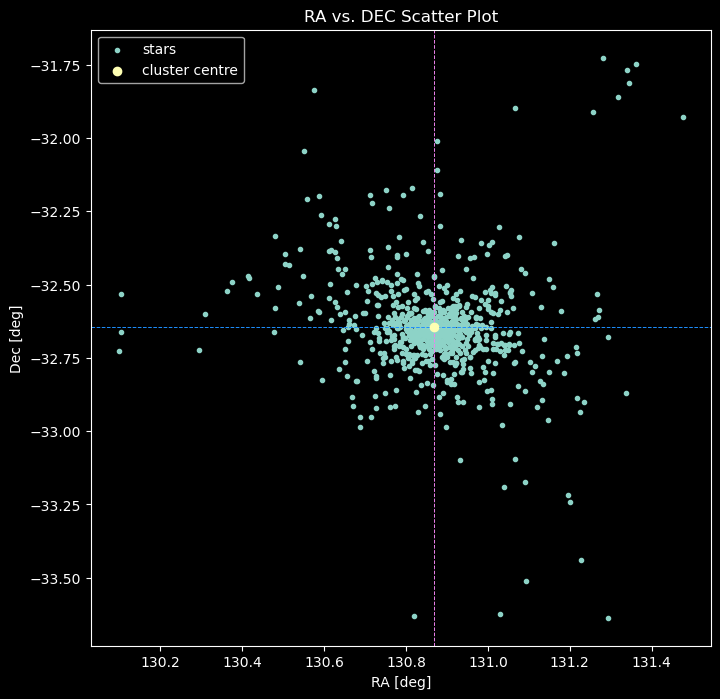

In [158]:
plt.figure(figsize = (8,8))
plt.scatter(my_cluster['RAdeg'], my_cluster['DEdeg'], marker = '.', label = 'stars')
plt.axvline(sph_center[0], ls = 'dashed', lw = 0.7, color = 'violet')
plt.axhline(sph_center[1], ls = 'dashed', lw = 0.7, color = 'dodgerblue')
plt.scatter(sph_center[0], sph_center[1], label = 'cluster centre', zorder=3)
plt.xlabel('RA [deg]')
plt.ylabel('Dec [deg]')
plt.legend()
plt.title('RA vs. DEC Scatter Plot')

# plt.figure(figsize = (8,8))
# plt.scatter(my_cluster['DEdeg'], my_cluster['RAdeg'], marker = '.', label = 'stars')
# plt.axhline(sph_center[0], ls = 'dashed', lw = 0.7, color = 'violet')
# plt.axvline(sph_center[1], ls = 'dashed', lw = 0.7, color = 'dodgerblue')
# plt.scatter(sph_center[1], sph_center[0], label = 'cluster centre', zorder=3)
# plt.ylabel('RA [deg]')
# plt.xlabel('Dec [deg]')
# plt.legend()
# plt.title('DEC vs. RA Scatter Plot')

In [159]:
print(f'total number of stars: {len(my_cluster)}')

total number of stars: 845


#### 1.b.ii *Comment on any structure you see in the scatter plot and how this might affect a radially binned profile.*

It seems that the cluster is generally pretty uniformly distributed in structure. However: 
- RA: I do see a slightly larger variance in Right Ascension on the left side of the cluster (evident with stars at the lower edge (< 130.2 deg), and also in the right-ward skew of the RA center coordinate (pink dashed line)). 

- DEC: 
        
    * i. to the left of center, there is slight asymmetry below and above the declination centre line (slightly more uniformly distributed along a 45 degree line from center towards upper left quadrant than the lower left quadrant, more densely clustered in center)

    * ii. to the right of center, there is a higher variance in declination than on the left side 

- overall, the cluster's structure tends to lie more prominently in the three regions encapsulated by ($\text{RA} \gt \text{RA}_{center}$ and $\text{DEC} \gt \text{DEC}_{center}$) 

- this might affect a radially binned profile by skewing distributions into this region and only being representative along certain slices

### 1.c. 
*We will now bin the stellar radii into a radial density profile by gathering all stars in annuli (donut-shaped area between two bounds $R_j$ and $R_{j+1}$). First, predict: How will the number of low-count bins change when going from $J = 15$ to $J = 50$ bins? Give a specific numeric expectation (e.g. “I expect the number of bins with counts $𝑁 < 5$ to increase by $X$ amount”) and justify your prediction using the scatter plot you’ve made.*

Answer: 

Here's what I know so far: there are 845 stars in my sample, and the scatter plot seems to show a spatial distribution that seems to increase exponentially in density towards the center coordinates (like if I were to draw a 45 degree line from the center outwards to the corners of my plots). 

With 15 bins, I anticipate the majority of the stars to be inside of the first (innermost radial) bin (~ 500), with the next 200 or so in the second innermost bin, and the final ~150 distributed within bins 3-6 and <30 in the bins 7-15, with the outermost bins having $N \lt 10$. 

From 15 to 50 bins, I anticipate that the number of bins with counts N < 5 to increase by a factor ~ 3.3 (50/15). I am looking at the scatter plot again, and when I don't divide by the center lines, I see that the cluster itself looks like it might have three arms, or at least three locations of outer density: 
1. Right of RA center \& above DEC center, 
2. Right of RA center \& below DEC center, 
3. left of RA center along DEC center line. 

These three dense spots actually seem pretty uniformly distributed (not exponential like the inner parts) so I would assume a linear (so just by factor 50/15) change in the low-count bins rather than a logarithmic one. 

### 1.d.

Set the maximum radius $R_{max}$ to the largest angular projected radius, and define bin edges 0 = $R_0 \lt R_1 \lt \cdots \lt R_J = R_{max}$. Make radial profiles for both $J = 15$ and $J = 50$. For each profile compute: 

* star counts $N_j$ for each annulus $j$ 

* the annulus area $A_j = \pi(R_{j + 1}^2 - R_j^2)(\text{arcmin}^2)$

* mid-radius $R_{j, mid} = \frac{(R_{j + 1}^2  + R_j^2)}{2}$

* empirical surface density: $\hat \Sigma_j = \frac{N_j}{A_j}$

* how many bins satisfy $N_j \lt 1$, $N_j \lt 5$, and $N_j \lt 10$



Just to keep track of the math: 
* defining the bins as instructed means that each bin j has stars with $R_j \leq R \leq R_{j + 1}$
* so, the edges array will have length $J + 1$

In [160]:
# set R_max 
Rmax = max(my_cluster['proj_radii'])
# set bin numbers
J_15 = 15
J_50 = 50
# define bin edges as arrays
bin_array_15 = np.linspace(0, Rmax, J_15 + 1)
bin_array_50 = np.linspace(0, Rmax, J_50 + 1)

I know I am kind of re-inventing the wheel in this next cell (as in there are much easier ways of doing this), but for some reason I decided to do it all out like this. 

In [161]:
def count_stars_annulus(bin_edges_array, cluster): 

    ''' INPUT DOCSTRING'''

    num_bins = len(bin_edges_array) - 1
    # setting up bin outputs for future list making
    bin_counts = np.zeros(num_bins, dtype=int)
    annulus_areas = np.zeros(num_bins, dtype = float)
    mid_radii = np.zeros(num_bins, dtype = float)
    surface_densities = np.zeros(num_bins, dtype = float)
    stars_binned = []

    # pulling out only relevant pieces of dataframe for this loop 
    names_proj_radii = cluster[['Name', 'proj_radii']] # dataframe of interest

    for j in range(num_bins): 
        # define annulus 
        inner_annulus_boundary = bin_edges_array[j]
        outer_annulus_boundary = bin_edges_array[j+1]
        annulus_area = np.pi*(outer_annulus_boundary**2 - inner_annulus_boundary**2)
        annulus_areas[j] = annulus_area
        mid_radii[j] = (outer_annulus_boundary + inner_annulus_boundary)/2
        # now doing counting 
        stars_in_bin = (names_proj_radii['proj_radii'] >= inner_annulus_boundary) & (names_proj_radii['proj_radii'] < outer_annulus_boundary)
        bin_counts[j] = np.sum(stars_in_bin)
        binned_stars_with_names = names_proj_radii.loc[stars_in_bin]
        stars_binned.append(binned_stars_with_names)
        # calculate surface density 
        surface_densities[j] = bin_counts[j]/annulus_area

    question_1d_dict = {'bin counts': bin_counts, 
                        'annulus areas': annulus_areas, 
                        'mid-radii': mid_radii, 
                        'surface density': surface_densities, 
                        'stars in bins': stars_binned}
    
    binning_dataframe_nonames = pd.DataFrame(question_1d_dict).drop(columns = 'stars in bins') 

    N_less_than_1 = np.sum(bin_counts < 1)
    N_less_than_5 = np.sum(bin_counts < 5)
    N_less_than_10 = np.sum(bin_counts < 10)

    low_counts = [N_less_than_1, 
                  N_less_than_5, 
                  N_less_than_10]
    print(f'N < 1: {low_counts[0]}')
    print(f'N < 5: {low_counts[1]}')
    print(f'N < 10: {low_counts[2]}')
    
    return binning_dataframe_nonames, low_counts, question_1d_dict


For simplicity, I asked ChatGPT to write me a better version of that function: 

In [187]:

def radial_profile_simple(cluster, J, print_lowcounts='True'):
    """
    Q1(d) simplest implementation:
    - define bin edges from 0 to Rmax
    - count stars per annulus
    - compute annulus area, mid-radius, and surface density
    """
    r = cluster["proj_radii"].to_numpy()

    Rmax = r.max()
    edges = np.linspace(0, Rmax, J + 1)   # bin edges: length J+1

    # star counts per bin
    N, _ = np.histogram(r, bins=edges)

    # annulus areas (arcmin^2)
    A = np.pi * (edges[1:]**2 - edges[:-1]**2)

    # mid radius
    Rmid = 0.5 * (edges[1:] + edges[:-1])

    # empirical surface density
    Sigma_hat = N / A

    # package as a clean dataframe (nice for printing/plotting)
    df = pd.DataFrame({
        "j": np.arange(1, J + 1),
        "R_in": edges[:-1],
        "R_out": edges[1:],
        "R_mid": Rmid,
        "N": N,
        "Area": A,
        "Sigma_hat": Sigma_hat
    })

    # counts of low-count bins
    n_lt1  = np.sum(N < 1)
    n_lt5  = np.sum(N < 5)
    n_lt10 = np.sum(N < 10)

    print(f'N < 1: {n_lt1}')
    print(f'N < 5: {n_lt5}')
    print(f'N < 10: {n_lt10}')

    return df, (n_lt1, n_lt5, n_lt10), edges


In [188]:
df_simple_15, low_counts_15, edges_15 = radial_profile_simple(cluster = my_cluster, J = 15, print_lowcounts = 'True')

N < 1: 0
N < 5: 6
N < 10: 8


In [109]:
binning_15, _, __ = count_stars_annulus(bin_array_15, my_cluster)
print('15-bin results: ')
binning_15

N < 1: 0
N < 5: 6
N < 10: 8
15-bin results: 


,bin counts,annulus areas,mid-radii,surface density
0,343,55.6926,2.1052,6.1588
1,210,167.0778,6.3156,1.2569
2,122,278.4630,10.5260,0.4381
3,57,389.8481,14.7364,0.1462
4,48,501.2333,18.9468,0.0958
5,22,612.6185,23.1572,0.0359
6,17,724.0037,27.3676,0.0235
7,4,835.3889,31.5780,0.0048
8,1,946.7741,35.7884,0.0011
9,7,1058.1592,39.9988,0.0066


In [103]:
df_simple_15['Area'] == binning_15['annulus areas']

0     True
1     True
2     True
3     True
4     True
5     True
6     True
7     True
8     True
9     True
10    True
11    True
12    True
13    True
14    True
dtype: bool

In [189]:
binning_50, _, __ = count_stars_annulus(bin_array_50, my_cluster)
print('50-bin results (trunc):')
binning_50.head(15)

N < 1: 12
N < 5: 28
N < 10: 34
50-bin results (trunc):


,bin counts,annulus areas,mid-radii,surface density
0,62,5.0123,0.6316,12.3695
1,126,15.0370,1.8947,8.3793
2,124,25.0617,3.1578,4.9478
3,86,35.0863,4.4209,2.4511
4,73,45.1110,5.6840,1.6182
5,48,55.1357,6.9472,0.8706
6,49,65.1603,8.2103,0.7520
7,45,75.1850,9.4734,0.5985
8,32,85.2097,10.7365,0.3755
9,30,95.2343,11.9997,0.3150


### 1e: *Make the following plots:*
* *$\hat \Sigma_j$ vs $R_{j,mid}$ with approximate uncertainty $\sqrt{\frac{N_j}{A_j}}$*

* *$N_j$ vs $R_{j,mid}$ with approximate uncertainty $\sqrt{N}$*

Note: these are good approximate uncertainties because this data is Poisson-distributed. 


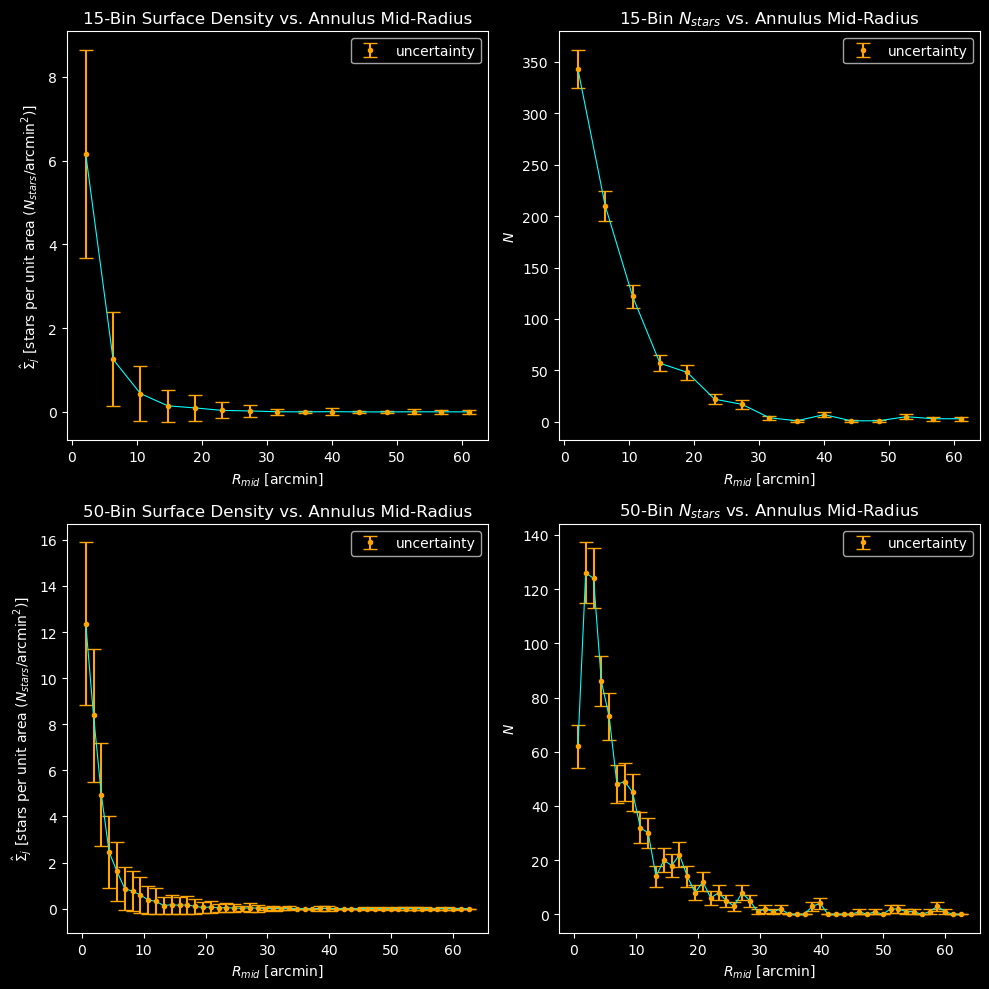

In [190]:
fig, ax = plt.subplots(2, 2, figsize = (10,10))

ax[0,0].errorbar(binning_15['mid-radii'], binning_15['surface density'], 
               yerr=np.sqrt(binning_15['bin counts']/binning_15['annulus areas']), 
               fmt='.', color = 'orange', capsize = 5, label = 'uncertainty')
ax[0,0].plot(binning_15['mid-radii'], binning_15['surface density'], color = 'cyan', lw = 0.8)
ax[0,0].set_xlabel('$R_{mid}$ [arcmin]')
ax[0,0].set_ylabel('$\hat \Sigma_j$ [stars per unit area ($N_{stars}/\\text{arcmin}^2$)]')
ax[0,0].set_title('15-Bin Surface Density vs. Annulus Mid-Radius')
ax[0,0].legend()

ax[0,1].errorbar(binning_15['mid-radii'], binning_15['bin counts'], 
               yerr=np.sqrt(binning_15['bin counts']), 
               fmt='.', color = 'orange', capsize = 5, label = 'uncertainty')
ax[0,1].plot(binning_15['mid-radii'], binning_15['bin counts'], color = 'cyan', lw = 0.8)
ax[0,1].set_xlabel('$R_{mid}$ [arcmin]')
ax[0,1].set_ylabel('$N$')
ax[0,1].set_title('15-Bin $N_{stars}$ vs. Annulus Mid-Radius')
ax[0,1].legend()

ax[1,0].errorbar(binning_50['mid-radii'], binning_50['surface density'], 
               yerr=np.sqrt(binning_50['bin counts']/binning_50['annulus areas']), 
               fmt='.', color = 'orange', capsize = 5, label = 'uncertainty')
ax[1,0].plot(binning_50['mid-radii'], binning_50['surface density'], color = 'cyan', lw = 0.8)
ax[1,0].set_xlabel('$R_{mid}$ [arcmin]')
ax[1,0].set_ylabel('$\hat \Sigma_j$ [stars per unit area ($N_{stars}/\\text{arcmin}^2$)]')
ax[1,0].set_title('50-Bin Surface Density vs. Annulus Mid-Radius')
ax[1,0].legend()


ax[1,1].errorbar(binning_50['mid-radii'], binning_50['bin counts'], 
               yerr=np.sqrt(binning_50['bin counts']), 
               fmt='.', color = 'orange', capsize = 5, label = 'uncertainty')
ax[1,1].plot(binning_50['mid-radii'], binning_50['bin counts'], color = 'cyan', lw = 0.8)
ax[1,1].set_xlabel('$R_{mid}$ [arcmin]')
ax[1,1].set_ylabel('$N$')
ax[1,1].set_title('50-Bin $N_{stars}$ vs. Annulus Mid-Radius')
ax[1,1].legend()
plt.tight_layout()



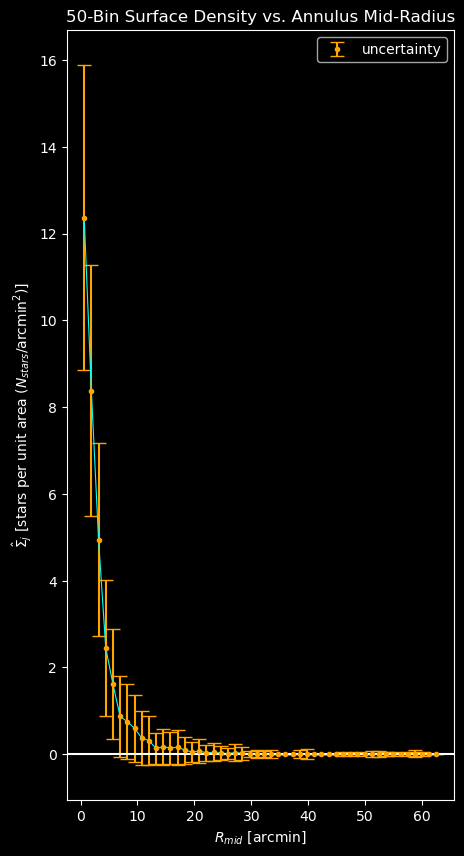

In [181]:
# question: why is it that the area smoothes things out and makes it nicer? and can i base my decision more on
# surface density than the counts? i think that makes sense given the areas of the bins are changing? 

fig, ax = plt.subplots(figsize = (5,10))

ax.errorbar(binning_50['mid-radii'], binning_50['surface density'], 
               yerr=np.sqrt(binning_50['bin counts']/binning_50['annulus areas']), 
               fmt='.', color = 'orange', capsize = 5, label = 'uncertainty')
ax.plot(binning_50['mid-radii'], binning_50['surface density'], color = 'cyan', lw = 0.8)
ax.axhline(0)
ax.set_xlabel('$R_{mid}$ [arcmin]')
ax.set_ylabel('$\hat \Sigma_j$ [stars per unit area ($N_{stars}/\\text{arcmin}^2$)]')
ax.set_title('50-Bin Surface Density vs. Annulus Mid-Radius')
ax.legend()

(array([10.,  0.,  2.,  0.,  0.,  1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,
         0.,  1.]),
 array([  1. ,  23.8,  46.6,  69.4,  92.2, 115. , 137.8, 160.6, 183.4,
        206.2, 229. , 251.8, 274.6, 297.4, 320.2, 343. ]),
 <BarContainer object of 15 artists>)

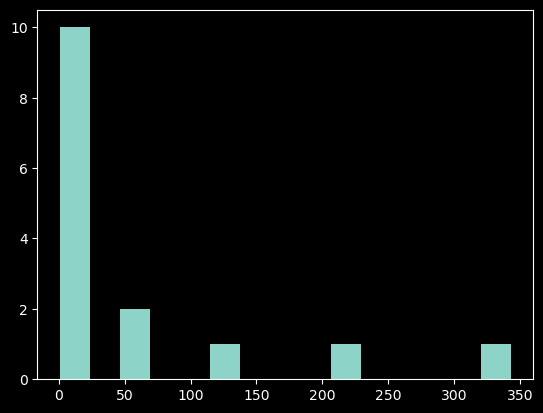

In [183]:
plt.hist(binning_15['bin counts'], bins = 15)

(array([30.,  4.,  3.,  2.,  1.,  1.,  1.,  0.,  1.,  2.,  0.,  0.,  1.,
         0.,  1.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  2.]),
 array([  0.  ,   5.04,  10.08,  15.12,  20.16,  25.2 ,  30.24,  35.28,
         40.32,  45.36,  50.4 ,  55.44,  60.48,  65.52,  70.56,  75.6 ,
         80.64,  85.68,  90.72,  95.76, 100.8 , 105.84, 110.88, 115.92,
        120.96, 126.  ]),
 <BarContainer object of 25 artists>)

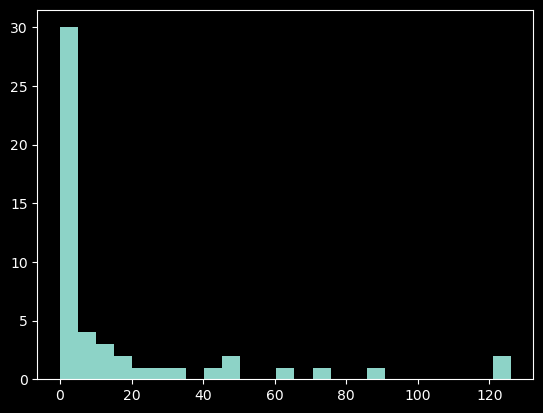

In [186]:
plt.hist(binning_50['bin counts'], bins = 25)

- for the 50-bin surface density, it goes to zero more consistently around 25 bins
- i think i'm going to use 25 bins 

## Exercise 2: Likelihood & Prior